# Compare Saved Brain Tumor MRI Models

This notebook compares **already-trained** models on the same test set.

## Supported comparison logic

This notebook is driven by two config lists:

- `METHOD_NAMES`
- `SEEDS`

Each combination `(method_name, seed)` maps to:

`models/<method_name>/seed_<seed>/best_pytorch.pt`

## Behavior rules

- If `METHOD_NAMES` has only one item, the notebook evaluates only that method.
- If `METHOD_NAMES` has multiple items, the notebook can compare methods under the same seed.
- If `SEEDS` has multiple items, the notebook reports mean/std across seeds **for each method**.
- No averaged confusion matrix is produced.

In [1]:
from pathlib import Path
import sys
import os

# Assume this notebook lives in: project_root/notebooks/
PROJECT_ROOT = Path.cwd().resolve().parent

# Make all relative paths behave as if the notebook is run from project root
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("Current working directory:", Path.cwd())

Project root: F:\brain-tumor-mri-classification
Current working directory: F:\brain-tumor-mri-classification


In [2]:
from itertools import product
from collections import defaultdict
from pathlib import Path
import csv
import re

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score

from src.data import create_dataloaders
from src.model import build_model
from src.train_eval import (
    set_seed,
    get_device,
    load_checkpoint,
    test_and_report,
)

## Configuration

Edit `METHOD_NAMES` and `SEEDS` below.

### Examples

Plain baselines:
- `"linear"`
- `"deep_mlp"`

Weighted CE variants:
- `"linear_weighted_ce_gli_1.3"`
- `"linear_weighted_ce_gli_3_men_1.2"`

### Expected checkpoint structure

- `models/linear/seed_1/best_pytorch.pt`
- `models/deep_mlp/seed_1/best_pytorch.pt`
- `models/linear_weighted_ce_gli_1.3/seed_1/best_pytorch.pt`

In [3]:
METHOD_NAMES = [
    "linear",
    "deep_mlp",
    "linear_weighted_ce_gli_1.3",
    # "linear_weighted_ce_gli_3_men_1.2",
]
SEEDS = [1, 2, 3]

IMG_SIZE = 256
BATCH_SIZE = 32
VAL_SPLIT = 0.2

DATA_ROOT = PROJECT_ROOT / "data"
MODELS_ROOT = PROJECT_ROOT / "models"
COMPARE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "comparisons"

SHOW_CONFUSION_MATRIX = True
SAVE_COMPARISON_PLOTS = True
SHOW_FULL_CLASSIFICATION_REPORTS = False
SAVE_SUMMARY_CSV = True

set_seed(42)
device = get_device()

print("Using device:", device)
print("Data root:", DATA_ROOT)
print("Models root:", MODELS_ROOT)
print("Method names:", METHOD_NAMES)
print("Seeds:", SEEDS)

Using device: cuda
Data root: F:\brain-tumor-mri-classification\data
Models root: F:\brain-tumor-mri-classification\models
Method names: ['linear', 'deep_mlp', 'linear_weighted_ce_gli_1.3']
Seeds: [1, 2, 3]


## Resolve method names

This helper reconstructs the backbone head configuration from the saved method name.

For evaluation, only the **head type** is required to rebuild the model before loading the checkpoint.

In [4]:
def resolve_method_name(method_name: str):
    method_name = str(method_name)

    if method_name == "linear":
        return {
            "method_name": method_name,
            "head_type": "linear",
            "class_weights": None,
        }

    if method_name == "deep_mlp":
        return {
            "method_name": method_name,
            "head_type": "deep_mlp",
            "class_weights": None,
        }

    weighted_pattern = r"^(linear|deep_mlp)_weighted_ce_(.+)$"
    match = re.match(weighted_pattern, method_name)
    if match:
        head_type = match.group(1)
        suffix = match.group(2)

        # Optional parsing of weight suffix for display only
        tokens = suffix.split("_")
        parsed_weights = {}
        i = 0
        while i + 1 < len(tokens):
            cls_abbr = tokens[i]
            weight_str = tokens[i + 1]
            try:
                parsed_weights[cls_abbr] = float(weight_str)
            except ValueError:
                pass
            i += 2

        return {
            "method_name": method_name,
            "head_type": head_type,
            "class_weights": parsed_weights if len(parsed_weights) > 0 else None,
        }

    raise ValueError(f"Unsupported METHOD_NAME: {method_name}")

In [5]:
for method_name in METHOD_NAMES:
    cfg = resolve_method_name(method_name)
    print(cfg)

{'method_name': 'linear', 'head_type': 'linear', 'class_weights': None}
{'method_name': 'deep_mlp', 'head_type': 'deep_mlp', 'class_weights': None}
{'method_name': 'linear_weighted_ce_gli_1.3', 'head_type': 'linear', 'class_weights': {'gli': 1.3}}


In [6]:
data_dict = create_dataloaders(
    data_root=str(DATA_ROOT),
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT,
    seed=42,
    device=device,
)

test_loader = data_dict["test_loader"]
class_names = data_dict["class_names"]

print("Classes:", class_names)
print("Train size:", data_dict["train_size"])
print("Val size:", data_dict["val_size"])
print("Test size:", data_dict["test_size"])

Dataset found: F:\brain-tumor-mri-classification\data
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train size: 4480
Val size: 1120
Test size: 1600


## Build requested experiment list

In [7]:
requested_configs = []
for method_name, seed in product(METHOD_NAMES, SEEDS):
    method_cfg = resolve_method_name(method_name)
    requested_configs.append(
        {
            "name": f"{method_name}_seed_{seed}",
            "method_name": method_name,
            "head_type": method_cfg["head_type"],
            "seed": seed,
            "checkpoint": MODELS_ROOT / method_name / f"seed_{seed}" / "best_pytorch.pt",
        }
    )

print("Requested model configurations:", len(requested_configs))
for cfg in requested_configs:
    print(" -", cfg["name"], "->", cfg["checkpoint"])

Requested model configurations: 9
 - linear_seed_1 -> F:\brain-tumor-mri-classification\models\linear\seed_1\best_pytorch.pt
 - linear_seed_2 -> F:\brain-tumor-mri-classification\models\linear\seed_2\best_pytorch.pt
 - linear_seed_3 -> F:\brain-tumor-mri-classification\models\linear\seed_3\best_pytorch.pt
 - deep_mlp_seed_1 -> F:\brain-tumor-mri-classification\models\deep_mlp\seed_1\best_pytorch.pt
 - deep_mlp_seed_2 -> F:\brain-tumor-mri-classification\models\deep_mlp\seed_2\best_pytorch.pt
 - deep_mlp_seed_3 -> F:\brain-tumor-mri-classification\models\deep_mlp\seed_3\best_pytorch.pt
 - linear_weighted_ce_gli_1.3_seed_1 -> F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_1\best_pytorch.pt
 - linear_weighted_ce_gli_1.3_seed_2 -> F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_2\best_pytorch.pt
 - linear_weighted_ce_gli_1.3_seed_3 -> F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_3\best_pytorch.pt


In [8]:
available_configs = []
missing_configs = []

for cfg in requested_configs:
    if Path(cfg["checkpoint"]).exists():
        available_configs.append(cfg)
    else:
        missing_configs.append(cfg)

print("Available checkpoints:", len(available_configs))
for cfg in available_configs:
    print("  [FOUND] ", cfg["name"], "->", cfg["checkpoint"])

print("\nMissing checkpoints:", len(missing_configs))
for cfg in missing_configs:
    print("  [MISSING]", cfg["name"], "->", cfg["checkpoint"])

Available checkpoints: 8
  [FOUND]  linear_seed_1 -> F:\brain-tumor-mri-classification\models\linear\seed_1\best_pytorch.pt
  [FOUND]  linear_seed_2 -> F:\brain-tumor-mri-classification\models\linear\seed_2\best_pytorch.pt
  [FOUND]  linear_seed_3 -> F:\brain-tumor-mri-classification\models\linear\seed_3\best_pytorch.pt
  [FOUND]  deep_mlp_seed_1 -> F:\brain-tumor-mri-classification\models\deep_mlp\seed_1\best_pytorch.pt
  [FOUND]  deep_mlp_seed_2 -> F:\brain-tumor-mri-classification\models\deep_mlp\seed_2\best_pytorch.pt
  [FOUND]  linear_weighted_ce_gli_1.3_seed_1 -> F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_1\best_pytorch.pt
  [FOUND]  linear_weighted_ce_gli_1.3_seed_2 -> F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_2\best_pytorch.pt
  [FOUND]  linear_weighted_ce_gli_1.3_seed_3 -> F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_3\best_pytorch.pt

Missing checkpoints: 1
  [MISSING] deep_mlp_seed_3 -> 

## Helper functions

In [9]:
COMPARE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)
    return path


def print_table(rows, columns):
    if len(rows) == 0:
        print("No rows to display.")
        return

    widths = {}
    for col in columns:
        widths[col] = max(
            len(col),
            max(len(str(row.get(col, ""))) for row in rows)
        )

    header = "  ".join(col.ljust(widths[col]) for col in columns)
    sep = "  ".join("-" * widths[col] for col in columns)

    print(header)
    print(sep)
    for row in rows:
        print("  ".join(str(row.get(col, "")).ljust(widths[col]) for col in columns))


def save_rows_to_csv(rows, columns, save_path: Path):
    ensure_dir(save_path.parent)
    with open(save_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=columns)
        writer.writeheader()
        for row in rows:
            writer.writerow({col: row.get(col, "") for col in columns})
    print("Saved CSV to:", save_path)


def save_bar_plot(labels, values, title, ylabel, save_path: Path, errors=None):
    ensure_dir(save_path.parent)
    x = np.arange(len(labels))

    plt.figure(figsize=(8, 5))
    if errors is not None:
        plt.bar(x, values, yerr=errors, capsize=5)
    else:
        plt.bar(x, values)

    plt.xticks(x, labels, rotation=30, ha="right")
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print("Saved plot to:", save_path)
    plt.show()


def summarize_by_method(results):
    grouped = defaultdict(list)
    for row in results:
        grouped[row["method_name"]].append(row)

    summary_rows = []
    for method_name in sorted(grouped.keys()):
        rows = grouped[method_name]

        accs = [r["accuracy"] for r in rows]
        macro_f1s = [r["macro_f1"] for r in rows]
        weighted_f1s = [r["weighted_f1"] for r in rows]

        summary_rows.append(
            {
                "method_name": method_name,
                "n_models": len(rows),
                "mean_accuracy": f"{np.mean(accs):.4f}",
                "std_accuracy": f"{np.std(accs):.4f}",
                "mean_macro_f1": f"{np.mean(macro_f1s):.4f}",
                "std_macro_f1": f"{np.std(macro_f1s):.4f}",
                "mean_weighted_f1": f"{np.mean(weighted_f1s):.4f}",
                "std_weighted_f1": f"{np.std(weighted_f1s):.4f}",
            }
        )

    return summary_rows

## Evaluate all available checkpoints

Evaluating: linear_seed_1
Method name: linear
Head type: linear
Seed: 1
Checkpoint: F:\brain-tumor-mri-classification\models\linear\seed_1\best_pytorch.pt


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

Test accuracy: 0.92375
Classification report:
              precision    recall  f1-score   support

      glioma       0.98      0.77      0.87       400
  meningioma       0.85      0.94      0.89       400
     notumor       0.92      0.99      0.96       400
   pituitary       0.96      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600

Confusion matrix saved to: outputs\linear\seed_1\confusion_matrix_test.png


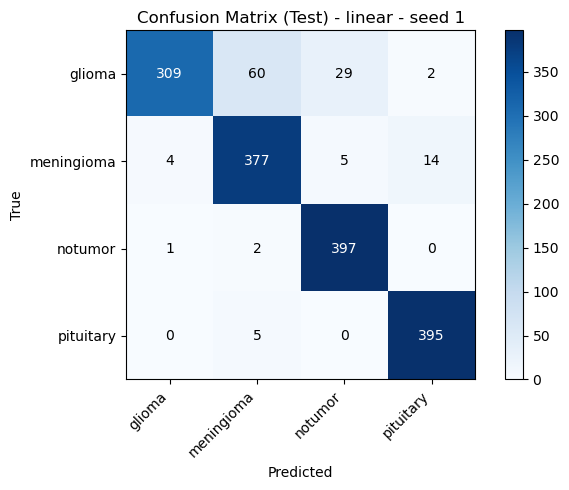

Evaluating: linear_seed_2
Method name: linear
Head type: linear
Seed: 2
Checkpoint: F:\brain-tumor-mri-classification\models\linear\seed_2\best_pytorch.pt


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

Test accuracy: 0.905625
Classification report:
              precision    recall  f1-score   support

      glioma       0.96      0.76      0.84       400
  meningioma       0.86      0.89      0.88       400
     notumor       0.85      0.99      0.92       400
   pituitary       0.97      0.98      0.98       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.90      1600
weighted avg       0.91      0.91      0.90      1600

Confusion matrix saved to: outputs\linear\seed_2\confusion_matrix_test.png


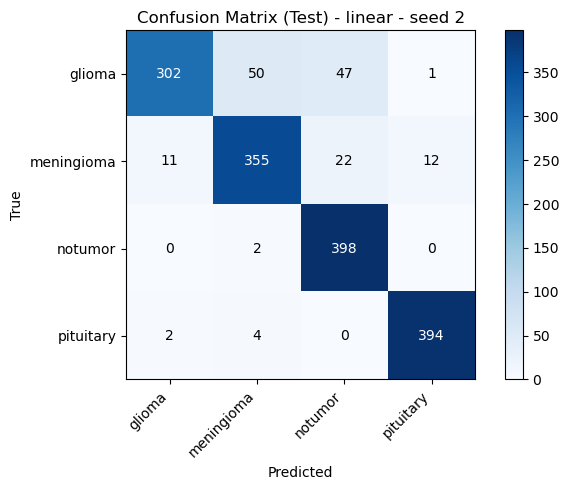

Evaluating: linear_seed_3
Method name: linear
Head type: linear
Seed: 3
Checkpoint: F:\brain-tumor-mri-classification\models\linear\seed_3\best_pytorch.pt


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

Test accuracy: 0.934375
Classification report:
              precision    recall  f1-score   support

      glioma       0.98      0.81      0.88       400
  meningioma       0.88      0.95      0.91       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.98      0.98      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600

Confusion matrix saved to: outputs\linear\seed_3\confusion_matrix_test.png


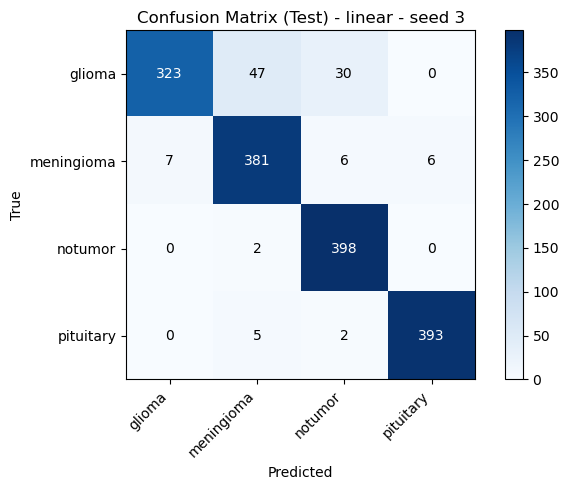

Evaluating: deep_mlp_seed_1
Method name: deep_mlp
Head type: deep_mlp
Seed: 1
Checkpoint: F:\brain-tumor-mri-classification\models\deep_mlp\seed_1\best_pytorch.pt


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

Test accuracy: 0.8575
Classification report:
              precision    recall  f1-score   support

      glioma       0.90      0.76      0.82       400
  meningioma       0.87      0.72      0.79       400
     notumor       0.79      0.99      0.88       400
   pituitary       0.89      0.96      0.92       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.85      1600
weighted avg       0.86      0.86      0.85      1600

Confusion matrix saved to: outputs\deep_mlp\seed_1\confusion_matrix_test.png


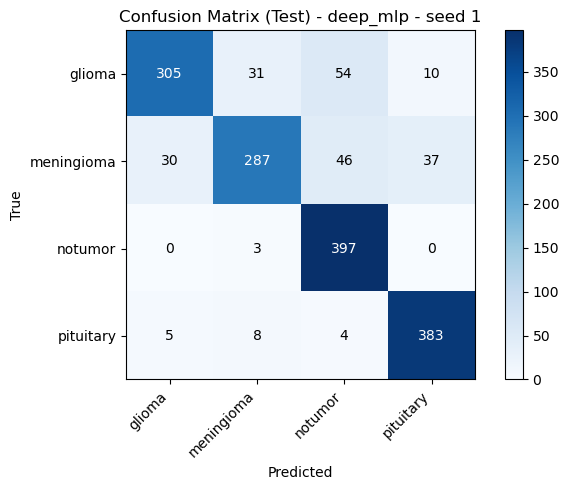

Evaluating: deep_mlp_seed_2
Method name: deep_mlp
Head type: deep_mlp
Seed: 2
Checkpoint: F:\brain-tumor-mri-classification\models\deep_mlp\seed_2\best_pytorch.pt


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

Test accuracy: 0.871875
Classification report:
              precision    recall  f1-score   support

      glioma       0.97      0.68      0.80       400
  meningioma       0.79      0.83      0.81       400
     notumor       0.86      0.99      0.92       400
   pituitary       0.90      0.98      0.94       400

    accuracy                           0.87      1600
   macro avg       0.88      0.87      0.87      1600
weighted avg       0.88      0.87      0.87      1600

Confusion matrix saved to: outputs\deep_mlp\seed_2\confusion_matrix_test.png


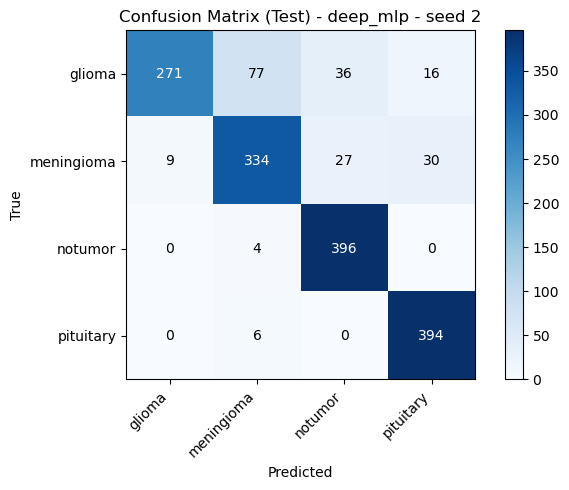

Evaluating: linear_weighted_ce_gli_1.3_seed_1
Method name: linear_weighted_ce_gli_1.3
Head type: linear
Seed: 1
Checkpoint: F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_1\best_pytorch.pt


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

Test accuracy: 0.9275
Classification report:
              precision    recall  f1-score   support

      glioma       0.98      0.80      0.88       400
  meningioma       0.86      0.93      0.89       400
     notumor       0.93      0.99      0.96       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600

Confusion matrix saved to: outputs\linear_weighted_ce_gli_1.3\seed_1\confusion_matrix_test.png


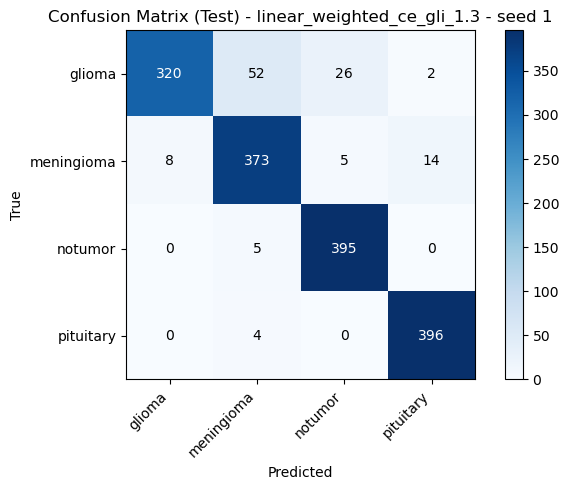

Evaluating: linear_weighted_ce_gli_1.3_seed_2
Method name: linear_weighted_ce_gli_1.3
Head type: linear
Seed: 2
Checkpoint: F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_2\best_pytorch.pt


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

Test accuracy: 0.93125
Classification report:
              precision    recall  f1-score   support

      glioma       0.98      0.81      0.88       400
  meningioma       0.87      0.94      0.90       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.98      0.98      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600

Confusion matrix saved to: outputs\linear_weighted_ce_gli_1.3\seed_2\confusion_matrix_test.png


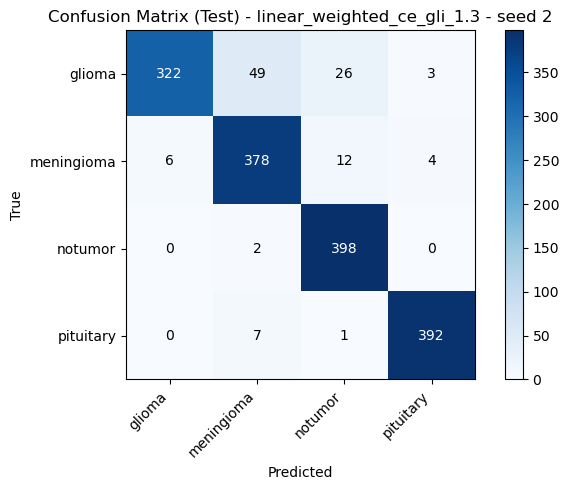

Evaluating: linear_weighted_ce_gli_1.3_seed_3
Method name: linear_weighted_ce_gli_1.3
Head type: linear
Seed: 3
Checkpoint: F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_3\best_pytorch.pt


F:\brain-tumor-mri-classification\src\train_eval.py:260: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint_path, map_location=device)

Test accuracy: 0.938125
Classification report:
              precision    recall  f1-score   support

      glioma       0.96      0.83      0.89       400
  meningioma       0.91      0.93      0.92       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.99      0.99      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.94      1600
weighted avg       0.94      0.94      0.94      1600

Confusion matrix saved to: outputs\linear_weighted_ce_gli_1.3\seed_3\confusion_matrix_test.png


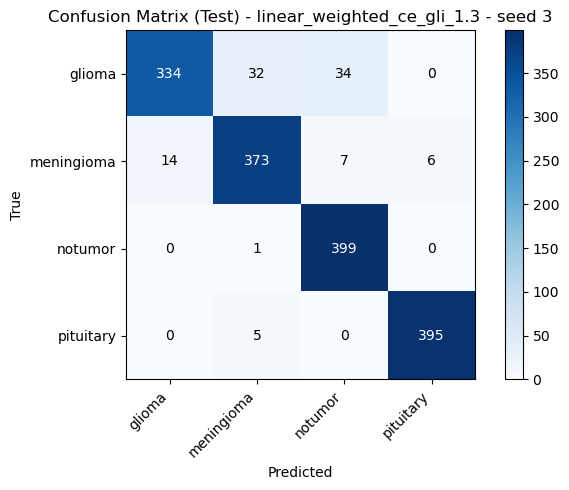

In [10]:
all_results = []

for cfg in available_configs:
    print("=" * 100)
    print("Evaluating:", cfg["name"])
    print("Method name:", cfg["method_name"])
    print("Head type:", cfg["head_type"])
    print("Seed:", cfg["seed"])
    print("Checkpoint:", cfg["checkpoint"])

    model, backbone_name = build_model(
        num_classes=len(class_names),
        head_type=cfg["head_type"],
    )
    model = model.to(device)

    model = load_checkpoint(model, cfg["checkpoint"], device)

    results = test_and_report(
        model=model,
        test_loader=test_loader,
        class_names=class_names,
        device=device,
        show_confusion_matrix=SHOW_CONFUSION_MATRIX,
        method_name=cfg["method_name"],
        seed=cfg["seed"],
        save_confusion_matrix=True,
    )

    macro_f1 = f1_score(results["y_true"], results["y_pred"], average="macro")
    weighted_f1 = f1_score(results["y_true"], results["y_pred"], average="weighted")

    all_results.append(
        {
            "model_name": cfg["name"],
            "method_name": cfg["method_name"],
            "head_type": cfg["head_type"],
            "seed": cfg["seed"],
            "checkpoint": str(cfg["checkpoint"]),
            "backbone": backbone_name,
            "accuracy": float(results["accuracy"]),
            "macro_f1": float(macro_f1),
            "weighted_f1": float(weighted_f1),
            "report": results["report"],
            "confusion_matrix": results["confusion_matrix"],
        }
    )

## Individual model summary

In [11]:
if len(all_results) == 0:
    print("No available checkpoints were evaluated.")
else:
    individual_rows = []
    for row in sorted(all_results, key=lambda x: (x["method_name"], x["seed"])):
        individual_rows.append(
            {
                "model_name": row["model_name"],
                "method_name": row["method_name"],
                "head_type": row["head_type"],
                "seed": row["seed"],
                "accuracy": f"{row['accuracy']:.4f}",
                "macro_f1": f"{row['macro_f1']:.4f}",
                "weighted_f1": f"{row['weighted_f1']:.4f}",
            }
        )

    print_table(
        individual_rows,
        ["model_name", "method_name", "head_type", "seed", "accuracy", "macro_f1", "weighted_f1"],
    )

    if SAVE_SUMMARY_CSV:
        save_rows_to_csv(
            individual_rows,
            ["model_name", "method_name", "head_type", "seed", "accuracy", "macro_f1", "weighted_f1"],
            COMPARE_OUTPUT_DIR / "individual_results.csv",
        )

model_name                         method_name                 head_type  seed  accuracy  macro_f1  weighted_f1
---------------------------------  --------------------------  ---------  ----  --------  --------  -----------
deep_mlp_seed_1                    deep_mlp                    deep_mlp   1     0.8575    0.8540    0.8540     
deep_mlp_seed_2                    deep_mlp                    deep_mlp   2     0.8719    0.8677    0.8677     
linear_seed_1                      linear                      linear     1     0.9237    0.9221    0.9221     
linear_seed_2                      linear                      linear     2     0.9056    0.9037    0.9037     
linear_seed_3                      linear                      linear     3     0.9344    0.9333    0.9333     
linear_weighted_ce_gli_1.3_seed_1  linear_weighted_ce_gli_1.3  linear     1     0.9275    0.9263    0.9263     
linear_weighted_ce_gli_1.3_seed_2  linear_weighted_ce_gli_1.3  linear     2     0.9313    0.9303    0.93

## Same-seed comparison across methods

This section is useful when you request multiple `METHOD_NAMES`.

For each seed, it compares all available methods under that same seed.

Seed 1 comparison
method_name                 accuracy  macro_f1  weighted_f1
--------------------------  --------  --------  -----------
deep_mlp                    0.8575    0.8540    0.8540     
linear                      0.9237    0.9221    0.9221     
linear_weighted_ce_gli_1.3  0.9275    0.9263    0.9263     
Saved CSV to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_1\method_comparison.csv
Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_1\accuracy_comparison.png


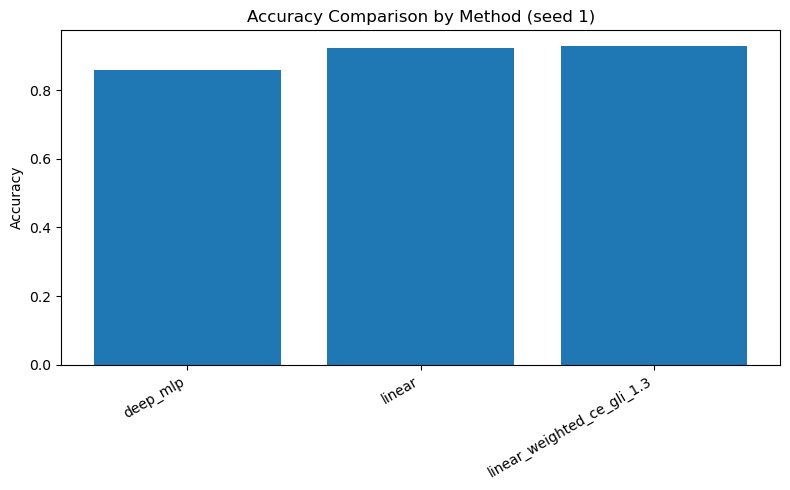

Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_1\macro_f1_comparison.png


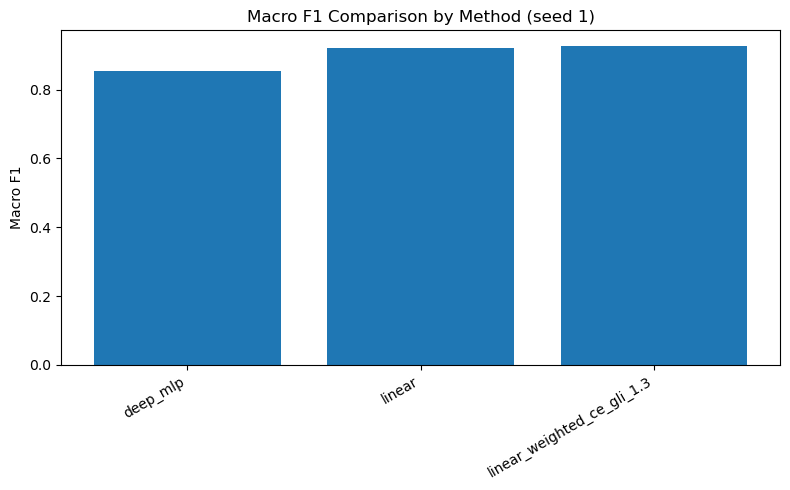

Seed 2 comparison
method_name                 accuracy  macro_f1  weighted_f1
--------------------------  --------  --------  -----------
deep_mlp                    0.8719    0.8677    0.8677     
linear                      0.9056    0.9037    0.9037     
linear_weighted_ce_gli_1.3  0.9313    0.9303    0.9303     
Saved CSV to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_2\method_comparison.csv
Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_2\accuracy_comparison.png


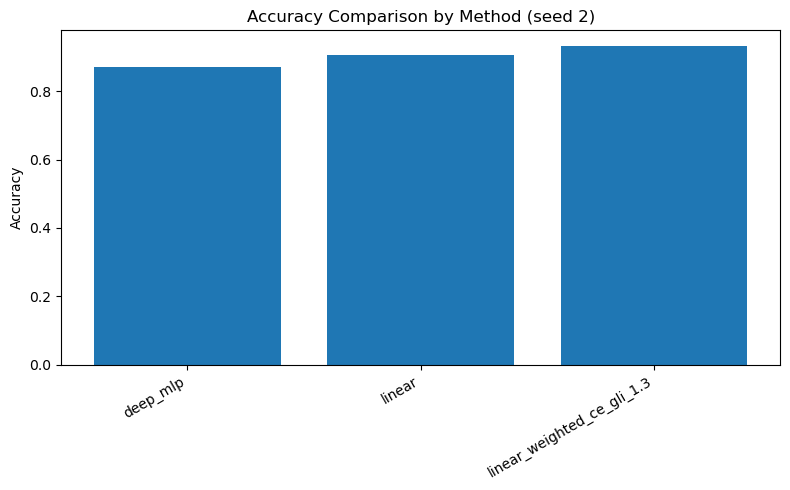

Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_2\macro_f1_comparison.png


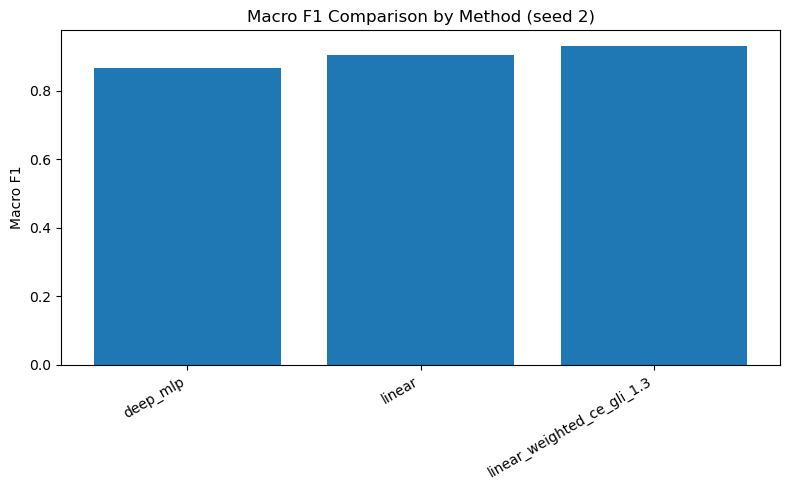

Seed 3 comparison
method_name                 accuracy  macro_f1  weighted_f1
--------------------------  --------  --------  -----------
linear                      0.9344    0.9333    0.9333     
linear_weighted_ce_gli_1.3  0.9381    0.9373    0.9373     
Saved CSV to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_3\method_comparison.csv
Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_3\accuracy_comparison.png


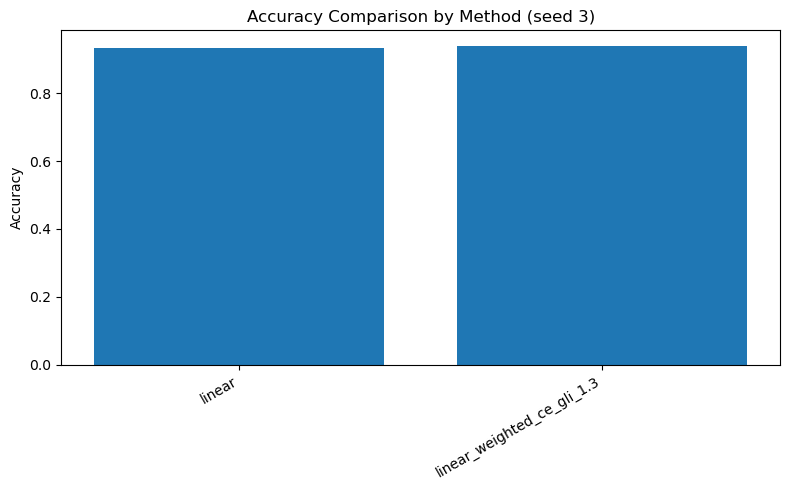

Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\seed_3\macro_f1_comparison.png


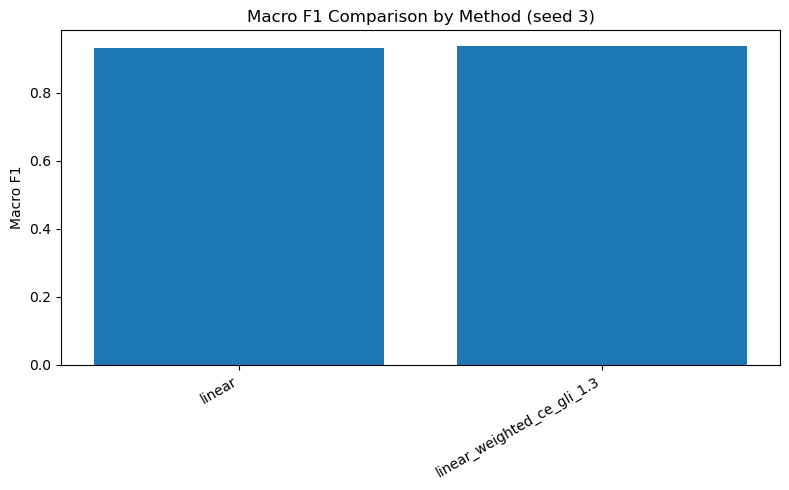

In [12]:
seed_grouped = defaultdict(list)
for row in all_results:
    seed_grouped[row["seed"]].append(row)

for seed in sorted(seed_grouped.keys()):
    rows = seed_grouped[seed]
    rows = sorted(rows, key=lambda x: x["method_name"])

    print("=" * 100)
    print(f"Seed {seed} comparison")

    display_rows = []
    for row in rows:
        display_rows.append(
            {
                "method_name": row["method_name"],
                "accuracy": f"{row['accuracy']:.4f}",
                "macro_f1": f"{row['macro_f1']:.4f}",
                "weighted_f1": f"{row['weighted_f1']:.4f}",
            }
        )

    print_table(display_rows, ["method_name", "accuracy", "macro_f1", "weighted_f1"])

    if SAVE_SUMMARY_CSV:
        save_rows_to_csv(
            display_rows,
            ["method_name", "accuracy", "macro_f1", "weighted_f1"],
            COMPARE_OUTPUT_DIR / f"seed_{seed}" / "method_comparison.csv",
        )

    if len(rows) >= 2 and SAVE_COMPARISON_PLOTS:
        labels = [row["method_name"] for row in rows]
        accs = [row["accuracy"] for row in rows]

        save_bar_plot(
            labels=labels,
            values=accs,
            title=f"Accuracy Comparison by Method (seed {seed})",
            ylabel="Accuracy",
            save_path=COMPARE_OUTPUT_DIR / f"seed_{seed}" / "accuracy_comparison.png",
        )

        macro_f1s = [row["macro_f1"] for row in rows]
        save_bar_plot(
            labels=labels,
            values=macro_f1s,
            title=f"Macro F1 Comparison by Method (seed {seed})",
            ylabel="Macro F1",
            save_path=COMPARE_OUTPUT_DIR / f"seed_{seed}" / "macro_f1_comparison.png",
        )

## Multi-seed summary by method

When there are multiple seeds, this section reports:
- per-method mean accuracy
- per-method std accuracy
- per-method mean / std macro F1
- per-method mean / std weighted F1

No averaged confusion matrix is produced.

method_name                 n_models  mean_accuracy  std_accuracy  mean_macro_f1  std_macro_f1  mean_weighted_f1  std_weighted_f1
--------------------------  --------  -------------  ------------  -------------  ------------  ----------------  ---------------
deep_mlp                    2         0.8647         0.0072        0.8608         0.0069        0.8608            0.0069         
linear                      3         0.9213         0.0119        0.9197         0.0122        0.9197            0.0122         
linear_weighted_ce_gli_1.3  3         0.9323         0.0044        0.9313         0.0045        0.9313            0.0045         
Saved CSV to: F:\brain-tumor-mri-classification\outputs\comparisons\multi_seed_summary.csv
Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\mean_accuracy_across_seeds.png


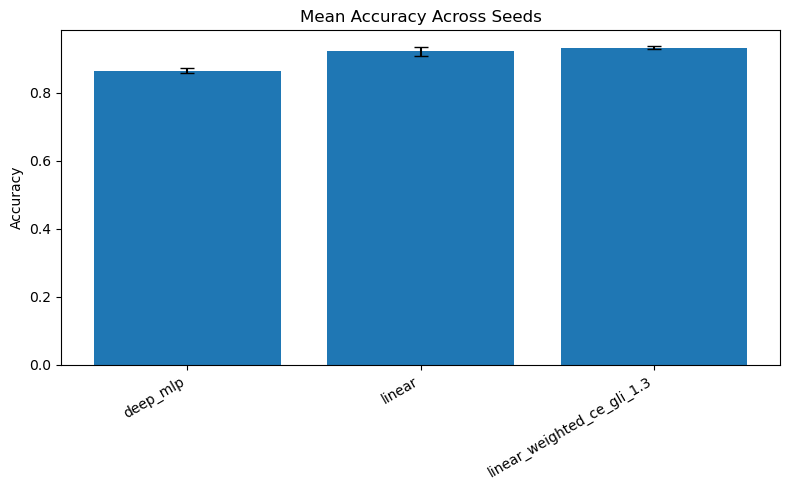

Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\mean_macro_f1_across_seeds.png


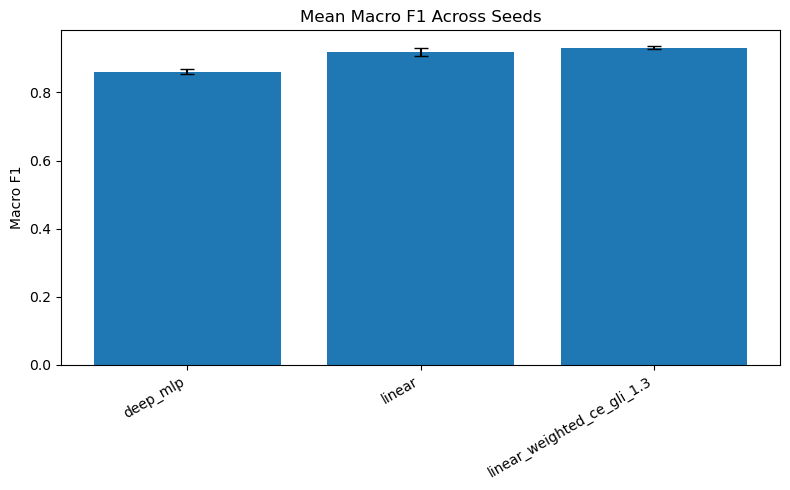

In [13]:
if len(SEEDS) >= 2 and len(all_results) > 0:
    summary_rows = summarize_by_method(all_results)

    print_table(
        summary_rows,
        [
            "method_name",
            "n_models",
            "mean_accuracy",
            "std_accuracy",
            "mean_macro_f1",
            "std_macro_f1",
            "mean_weighted_f1",
            "std_weighted_f1",
        ],
    )

    if SAVE_SUMMARY_CSV:
        save_rows_to_csv(
            summary_rows,
            [
                "method_name",
                "n_models",
                "mean_accuracy",
                "std_accuracy",
                "mean_macro_f1",
                "std_macro_f1",
                "mean_weighted_f1",
                "std_weighted_f1",
            ],
            COMPARE_OUTPUT_DIR / "multi_seed_summary.csv",
        )

    if SAVE_COMPARISON_PLOTS:
        labels = [row["method_name"] for row in summary_rows]
        mean_accs = [float(row["mean_accuracy"]) for row in summary_rows]
        std_accs = [float(row["std_accuracy"]) for row in summary_rows]

        save_bar_plot(
            labels=labels,
            values=mean_accs,
            errors=std_accs,
            title="Mean Accuracy Across Seeds",
            ylabel="Accuracy",
            save_path=COMPARE_OUTPUT_DIR / "mean_accuracy_across_seeds.png",
        )

        mean_macro_f1s = [float(row["mean_macro_f1"]) for row in summary_rows]
        std_macro_f1s = [float(row["std_macro_f1"]) for row in summary_rows]

        save_bar_plot(
            labels=labels,
            values=mean_macro_f1s,
            errors=std_macro_f1s,
            title="Mean Macro F1 Across Seeds",
            ylabel="Macro F1",
            save_path=COMPARE_OUTPUT_DIR / "mean_macro_f1_across_seeds.png",
        )
else:
    print("Multi-seed summary is skipped because fewer than 2 seeds were requested.")

## Per-method seed details

This section is helpful when one method has multiple seeds.

Method: deep_mlp
seed  accuracy  macro_f1  weighted_f1
----  --------  --------  -----------
1     0.8575    0.8540    0.8540     
2     0.8719    0.8677    0.8677     
Saved CSV to: F:\brain-tumor-mri-classification\outputs\comparisons\deep_mlp\seed_details.csv
Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\deep_mlp\accuracy_across_seeds.png


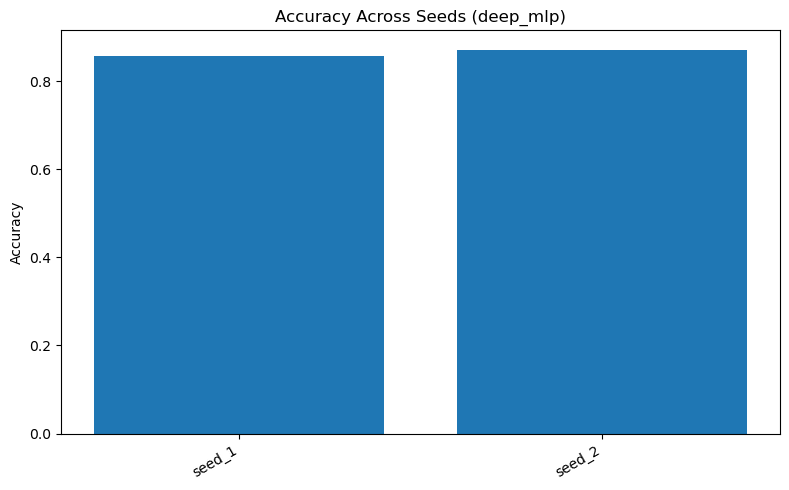

Method: linear
seed  accuracy  macro_f1  weighted_f1
----  --------  --------  -----------
1     0.9237    0.9221    0.9221     
2     0.9056    0.9037    0.9037     
3     0.9344    0.9333    0.9333     
Saved CSV to: F:\brain-tumor-mri-classification\outputs\comparisons\linear\seed_details.csv
Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\linear\accuracy_across_seeds.png


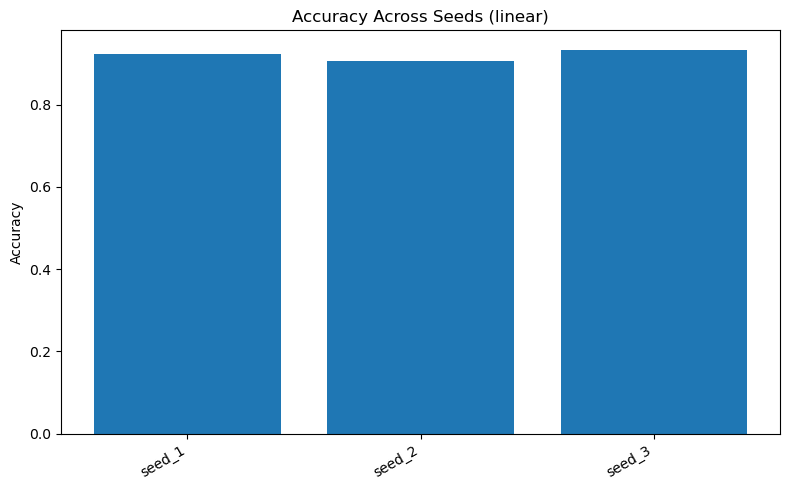

Method: linear_weighted_ce_gli_1.3
seed  accuracy  macro_f1  weighted_f1
----  --------  --------  -----------
1     0.9275    0.9263    0.9263     
2     0.9313    0.9303    0.9303     
3     0.9381    0.9373    0.9373     
Saved CSV to: F:\brain-tumor-mri-classification\outputs\comparisons\linear_weighted_ce_gli_1.3\seed_details.csv
Saved plot to: F:\brain-tumor-mri-classification\outputs\comparisons\linear_weighted_ce_gli_1.3\accuracy_across_seeds.png


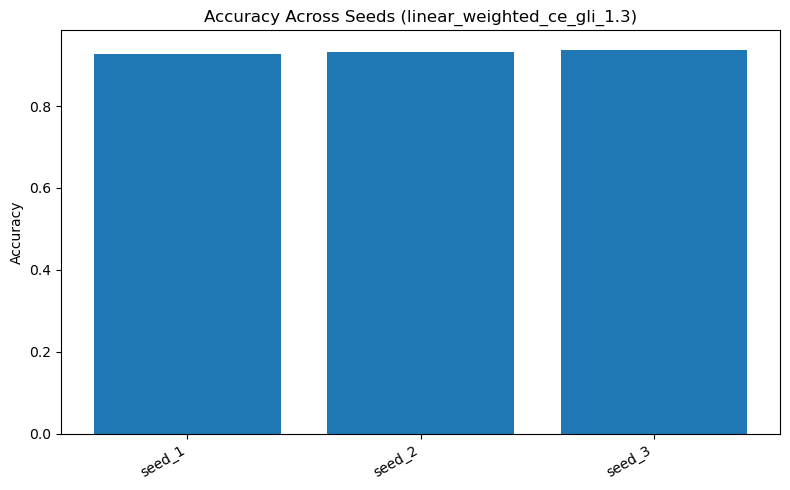

In [14]:
method_grouped = defaultdict(list)
for row in all_results:
    method_grouped[row["method_name"]].append(row)

for method_name in sorted(method_grouped.keys()):
    rows = sorted(method_grouped[method_name], key=lambda x: x["seed"])

    print("=" * 100)
    print(f"Method: {method_name}")

    display_rows = []
    for row in rows:
        display_rows.append(
            {
                "seed": row["seed"],
                "accuracy": f"{row['accuracy']:.4f}",
                "macro_f1": f"{row['macro_f1']:.4f}",
                "weighted_f1": f"{row['weighted_f1']:.4f}",
            }
        )

    print_table(display_rows, ["seed", "accuracy", "macro_f1", "weighted_f1"])

    if SAVE_SUMMARY_CSV:
        save_rows_to_csv(
            display_rows,
            ["seed", "accuracy", "macro_f1", "weighted_f1"],
            COMPARE_OUTPUT_DIR / method_name / "seed_details.csv",
        )

    if len(rows) >= 2 and SAVE_COMPARISON_PLOTS:
        labels = [f"seed_{row['seed']}" for row in rows]
        accs = [row["accuracy"] for row in rows]

        save_bar_plot(
            labels=labels,
            values=accs,
            title=f"Accuracy Across Seeds ({method_name})",
            ylabel="Accuracy",
            save_path=COMPARE_OUTPUT_DIR / method_name / "accuracy_across_seeds.png",
        )

## Best available model

In [15]:
if len(all_results) == 0:
    print("No results to show.")
else:
    best_result = max(all_results, key=lambda x: x["accuracy"])

    print("Best model:")
    print("  model_name :", best_result["model_name"])
    print("  method_name:", best_result["method_name"])
    print("  head_type  :", best_result["head_type"])
    print("  seed       :", best_result["seed"])
    print("  backbone   :", best_result["backbone"])
    print("  accuracy   :", f"{best_result['accuracy']:.4f}")
    print("  macro_f1   :", f"{best_result['macro_f1']:.4f}")
    print("  weighted_f1:", f"{best_result['weighted_f1']:.4f}")
    print("  checkpoint :", best_result["checkpoint"])

Best model:
  model_name : linear_weighted_ce_gli_1.3_seed_3
  method_name: linear_weighted_ce_gli_1.3
  head_type  : linear
  seed       : 3
  backbone   : torchvision:resnet50 + linear
  accuracy   : 0.9381
  macro_f1   : 0.9373
  weighted_f1: 0.9373
  checkpoint : F:\brain-tumor-mri-classification\models\linear_weighted_ce_gli_1.3\seed_3\best_pytorch.pt


## Optional: full classification reports

In [16]:
if SHOW_FULL_CLASSIFICATION_REPORTS:
    for row in all_results:
        print("=" * 100)
        print("Model:", row["model_name"])
        print("Method name:", row["method_name"])
        print("Head type:", row["head_type"])
        print("Seed:", row["seed"])
        print("Accuracy:", f"{row['accuracy']:.4f}")
        print("Macro F1:", f"{row['macro_f1']:.4f}")
        print("Weighted F1:", f"{row['weighted_f1']:.4f}")
        print("\nClassification report:")
        print(row["report"])
else:
    print("Set SHOW_FULL_CLASSIFICATION_REPORTS = True to print full reports.")

Set SHOW_FULL_CLASSIFICATION_REPORTS = True to print full reports.
